Course: Diffuse and Stochastic Processes, Namiko Mitarai, NBI, University of Copenhagen

Assignment Part 2

Peter Resch, 31.5.2026

# Gillespie simulation of fermentation metabolism

# a) Propose a reaction scheme

## Briefly describe motivation for model
When fermenting food, one type of bacteria group is often found - acid bacteria. In a rough explanation, they essentially metabolize sugars into acids and other metabolites, which we will not describe further for this simplified model. For fermenting purposes, this is often wanted in terms of longer preservation of food by lowering the pH level or also for flavours (e.g. yoghurt, salami, sauerkraut, kombucha).
One of the first steps in fermentation is to add starter culture, to introduce a major amount of the wanted bacteria to the substrate, so that they can take the lead in civilizing before other microorganism can do this. You could also do this without, which is then often called wild fermentation. The lowering of pH levels is a great way to preserve foods, as each microorganism has their own preferred milieu (pH-value, temperature, substrate, airsupply) and the acid bacteria group is one, which like it sour and also produce acids themselves.
I came up with an idea to model a metabolite process of kombucha - a tea based drink, which ferments sugar over time, where acetic acid bacteria play a major role.

## Write the full reaction scheme, including all propensity functions and parameter values
To keep this model as simple, but still functional as possible, I selected three processes, which are relevant and three amounts of populations, which interact with each other.
There is the amount of Sugar given as $S$, the amount of H^{+} ions in the liquid as $H$ and the population of active bacteria $N$. As the dynamics in this model depend on populations in a certain volume, these sizes are defined in units per liter.

The population of bacteria can grow by eating sugar, the rate depending on the concentration $N$ and $S$ in the volume, where $\lambda$ is the coeffecient of growth - $g(N,S,\lambda)= N S \lambda$ - $N + S -> N+1 + S-1$

The population can also become really slow in reproduction and metabolizing (deactivated) or dies, which is dependent on the deviation from the neutral pH level (pH=7) of the liquid and should resamble a exponential decay - $d(H,\gamma)=(7-pH(H))\gamma N$ - $N -> N-1$

The bacteria can also metabolize sugar to $\alpha * H^{+}$ ions without growing, which in an simple assumption has a rate multiplicative rate to the growth process, as it should be dependend on the same parameters - $m(N,S,\lambda,\mu)=\mu g(N,S,\lambda)$ - $S + H -> \alpha*(H+1) + S-1$


## Discuss expected mean behaviour
My expection of the behaviour is, that after inital exponential growth of the bacteria population and H^{+}, the growth will flatten and stabilize due to a higher pH level. The pH should still be raising, until all sugar is consumed. Thereafter, the pH should stay the same and the bacteria population should continously go down, with exponential decay.

## predict wether fluctuations will be large or small rel to mean & justify by the structure of the model
In the period of exponential growth, I suspect large deviation for each trajectory and therefore in the variance. As the system stabilizes due to the higher pH levels, I suspect that the variance could be small, relative to the mean. For the exponential decay of the population after the sugar is consumed, again large variance is suspected. My understanding of the inherence of these dynamics is due to the battling exponential growth and decay process structures of the model


(as there is a logarithm involved through the pH, the model might not be accurate)


In [97]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from tqdm import tqdm

r = np.random
r.seed(42)



#--------------------------------------------Functions--------------------------------------------
class H_plus_ions:#class to handle H+ ions and pH values per mol/liter
    pH_neutral=7
    scale=10**10

    @classmethod
    def scaled_to_pH(cls,scaled):
        mol=scaled/cls.scale
        pH=-np.log10(mol)
        return pH
    
    def __init__(self,H_scaled):
        self.scaled=H_scaled

    def __str__(self):
        return f"{self.scaled}"

    def give_pH(self):
        pH=-np.log10(self.give_mol())
        return pH

    def give_mol(self):
        mol=self.scaled/self.scale
        return mol
    
    def __add__(self,value):
        return H_plus_ions(self.scaled+value)



def rates_all_events(lam, gamma, mu, S, H, N):
    growth = N*S*lam
    degradation = (7-H.give_pH())*gamma*N
    metabolize = growth*mu
    return growth, degradation, metabolize

def event_time(K):
    r_tau=r.uniform()
    tau_event=-np.log(r_tau)/(K)   
    return tau_event

def event_type(g,d,m):
    K=g+d+m
    r_event=r.uniform()
    if r_event < g/K:
        return 'growth'
    elif g/K<r_event and r_event<(g+d)/K:
        return 'degradation'
    else:
        return 'metabolize'


def simulate_1_step(lam, gamma, mu,alpha, S, H, N):
    g,d,m=rates_all_events(lam, gamma, mu, S, H, N)
    K=g+d+m
    if K==0:
        print(f"No events possible, K=0: growth: {g}, degradation: {d}, metabolize: {m}; S: {S}, H: {H}, N: {N}")
        return [S,H,N],0
    e_type=event_type(g,d,m)
    e_tau=event_time(K)
    #print(f"{e_type} after {e_tau}")

    if e_type=="growth":
        N+=1
        S-=1
        if S<0:
            S=0
    elif e_type=="degradation":
        if N>1:
            N-=1
        else:
            N=0
    else:   #metabolize
        S-=1
        if S<0:
            S=0
        H=H+1*alpha
    return [S,H,N],e_tau



def simulate_metabolism(lam, gamma, mu,alpha, S, H, N, total_time):
    time = 0
    S_count = S
    H_count = H
    N_count = N

    S_array = [S]
    H_array = [H.scaled]
    N_array = [N]

    time_array = [time]

    while time < total_time:
        [S_count,H_count,N_count],tau=simulate_1_step(lam, gamma, mu,alpha, S_count,H_count,N_count)

        S_array.append(S_count)
        H_array.append(H_count.scaled)
        N_array.append(N_count)

        time=time+tau
        time_array.append(time)

        if len(time_array)%10000==0:
            print(f"Time: {time:.2f} of {total_time}, S: {S_count}, H: {H_count}, N: {N_count}, pH: {H_count.give_pH()}",end="\r")
    
    return np.array(time_array), [np.array(S_array),np.array(H_array),np.array(N_array)]

b) choose specific initial condition

choose duration justified by timescales of system

simulate long enough to see interesting dynamics

plot 3 traj

In [107]:
#----------Initial parameters------

alpha=1.0       #metabolism rate from S -> alpha*H
gamma=10**-4#0*2   #degrade factor of N population
lam=10**-8     #growth factor of N population,#*np.log(2)/(30*60) doubling time 30min
mu=2.0          #metabolism factor in relation to growthrate
#avogadro=6.022*10**23  #Avogadro's number


N=100                  #number of acid bacteria population/liter
pH_neutral=7        #mol H+ Ions/liter, pH=7 (neutral)
H=H_plus_ions(10**(-pH_neutral)*10**10) #initial mol H+ Ions/liter, using pH 7 as reference, scaled by 10^10

    

#Glucose C6H12O6,       180 g/mol, 1 mol = 180 g
#Saccharose C12H22O11,  342 g/mol, 1 mol = 342 g
S_in_gram=10**-2            #initial grams of sugar/liter in the system
S=S_in_gram/342*H_plus_ions.scale         #mol Sugar molecules/liter, using saccharose as reference


total_time=10000  #virtual timescale



print("-----Initial parameters:---------")
print(f"Alpha: {alpha}")
print(f"Gamma: {gamma}")
print(f"Lam: {lam}")
print(f"Mu: {mu}")
print(f"N: {N}")
print(f"S_in_gram: {S_in_gram}")
print(f"S: {S}")
print(f"H: {H}")
print(f"pH: {H.give_pH()}")
print(f"Total time: {total_time}")

print("-----------------------------------------")
g,d,m=rates_all_events(lam,gamma,mu,S,H,N)
K=g+m+d
print(f"g: {g}, d: {d}, m: {m}, K: {K}")
print(f"tau: {event_time(K)}")


-----Initial parameters:---------
Alpha: 1.0
Gamma: 0.0001
Lam: 1e-08
Mu: 2.0
N: 100
S_in_gram: 0.01
S: 292397.6608187135
H: 1000.0
pH: 7.0
Total time: 10000
-----------------------------------------
g: 0.2923976608187135, d: 0.0, m: 0.584795321637427, K: 0.8771929824561404
tau: 1.6622508153083355


In [108]:
#Testing
print(H.give_pH(),f"for H {H}")
g,d,m=rates_all_events(lam,gamma,mu,S,H,N)
K=g+m+d
print(f"g: {g}, d: {d}, m: {m}, K: {K}")
print(f"tau: {event_time(K)}")
print(f"event type: {event_type(g,d,m)}")

a=simulate_1_step(lam,gamma,mu,alpha,S,H,N)
print(f"S: {S}, H: {H}, N: {N}")
print(f"a: {a}")


7.0 for H 1000.0
g: 0.2923976608187135, d: 0.0, m: 0.584795321637427, K: 0.8771929824561404
tau: 0.03319354380264865
event type: growth
S: 292397.6608187135, H: 1000.0, N: 100
a: ([292396.6608187135, <__main__.H_plus_ions object at 0x79af86be9c90>, 101], np.float64(2.507108229802824))


In [116]:
num_simulations=3

simulation_times = []
simulation_counts_S = []
simulation_counts_N = []
simulation_counts_H = []

for _ in tqdm(range(num_simulations)):
    times, [counts_S,counts_H,counts_N] = simulate_metabolism(lam, gamma, mu,alpha, S, H, N, total_time)
    #print(len(times))
    #print(len(counts_S))
    #print(counts_S[0])
    simulation_times.append(times)
    simulation_counts_S.append(counts_S)
    simulation_counts_N.append(counts_N)
    simulation_counts_H.append(counts_H)
    print(len(times))

print("Done!")

  0%|          | 0/3 [00:00<?, ?it/s]

 33%|███▎      | 1/3 [00:07<00:15,  7.82s/it]

372091


 67%|██████▋   | 2/3 [00:15<00:08,  8.02s/it]

372272


100%|██████████| 3/3 [00:24<00:00,  8.12s/it]

371597
Done!


## Plot trajectories

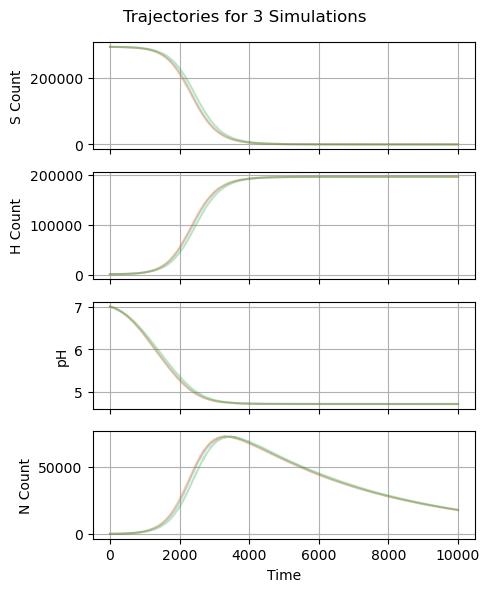

In [119]:
#plot counts vs time for each simulation
fig,ax=plt.subplots(4, 1, figsize=(5, 6),sharex=True)
for i in range(num_simulations):
    ax[0].plot(simulation_times[i], simulation_counts_S[i], alpha=0.3)
    ax[1].plot(simulation_times[i], simulation_counts_H[i], alpha=0.3)
    ax[2].plot(simulation_times[i], H_plus_ions.scaled_to_pH(simulation_counts_H[i]), alpha=0.3)
    ax[3].plot(simulation_times[i], simulation_counts_N[i], alpha=0.3)

ax[3].set_xlabel('Time')

fig.suptitle(rf'Trajectories for {num_simulations} Simulations')

ax[0].set_ylabel('S Count')
ax[1].set_ylabel('H Count')
ax[2].set_ylabel('pH')
ax[3].set_ylabel('N Count')

ax[0].grid()
ax[1].grid()
ax[2].grid()
ax[3].grid()

plt.tight_layout()
fig.savefig('3trajectories.png', dpi=300)

In [120]:
i=0
simulation_counts_S[i][0]

np.float64(292397.6608187135)

In [121]:
i=0
rates_array=[]
times_array=[]
rates_to_calc=100
step_size = len(simulation_times[i]) // rates_to_calc

for t in range(0, len(simulation_times[i]), step_size):
    print(f"Calculating rates for time {t:.2f} of {simulation_times[i][-1]:.2f}", end="\r")
    times_array.append(t)
    rates_array.append(rates_all_events(lam,gamma,mu,simulation_counts_S[i][t],H_plus_ions(simulation_counts_H[i][t]),simulation_counts_N[i][t]))


In [122]:
rates_array=np.array(rates_array)

Text(0.5, 0, 'Time')

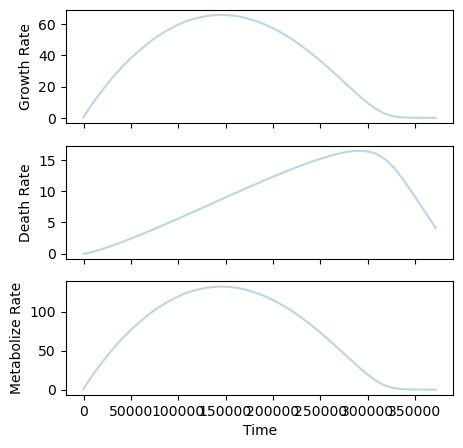

In [123]:
#plot rates of 1 trajectory
fig,ax=plt.subplots(3, 1, figsize=(5, 5),sharex=True)

ax[0].plot(times_array, rates_array[:,0], alpha=0.3)
ax[0].set_ylabel('Growth Rate')
ax[1].plot(times_array, rates_array[:,1], alpha=0.3)
ax[1].set_ylabel('Death Rate')
ax[2].plot(times_array, rates_array[:,2], alpha=0.3)
ax[2].set_ylabel('Metabolize Rate')
ax[2].set_xlabel('Time')
    

## Simulate 100 trajectories

c) for each species compute and plot
-ensemble averaged mean and 
-variance and 
-coeff of variation vs time

In [124]:
num_simulations=100

simulation_times = []
simulation_counts_S = []
simulation_counts_N = []
simulation_counts_H = []

for _ in tqdm(range(num_simulations)):
    times, [counts_S,counts_H,counts_N] = simulate_metabolism(lam, gamma, mu,alpha, S, H, N, total_time)
    #print(len(times))
    #print(len(counts_S))
    #print(counts_S[0])
    simulation_times.append(times)
    simulation_counts_S.append(counts_S)
    simulation_counts_N.append(counts_N)
    simulation_counts_H.append(counts_H)

print("Done!")

  0%|          | 0/100 [00:00<?, ?it/s]

  1%|          | 1/100 [00:07<12:38,  7.66s/it]

  2%|▏         | 2/100 [00:14<11:53,  7.28s/it]

  3%|▎         | 3/100 [00:22<11:54,  7.37s/it]

  4%|▍         | 4/100 [00:29<11:53,  7.44s/it]

...

 97%|█████████▋| 97/100 [13:33<00:25,  8.59s/it]

 98%|█████████▊| 98/100 [13:42<00:17,  8.63s/it]

 99%|█████████▉| 99/100 [13:51<00:08,  8.61s/it]

100%|██████████| 100/100 [13:59<00:00,  8.40s/it]

Done!


In [142]:
def n_at_time_t_per_simulation(time_array, event_count_array, t):
    if t < time_array[0]:
        print(f"Time {t} is before the first time point {time_array[0]}, returning initial count {event_count_array[0]}")
        return event_count_array[0]
    # Find the index of the last time point that is less than or equal to t
    index = np.searchsorted(time_array, t, side='right') - 1
    n_at_t = event_count_array[index]
    return n_at_t


def calc_stats_at_t(time_simulations, event_simulations, t):
    n_values = []
    for time_array, event_count_array in zip(time_simulations, event_simulations):
        n_at_t = n_at_time_t_per_simulation(time_array, event_count_array,t)
        n_values.append(n_at_t)
    n_values=np.array(n_values)

    mean=np.mean(n_values)
    var=np.var(n_values)
    if mean > 0:
        coeff_of_var=np.sqrt(var)/mean
    else:
        coeff_of_var=np.nan
    return mean, var, coeff_of_var


n_at_time_t_per_simulation(simulation_times[0], simulation_counts_S[0], 10)

calc_stats_at_t(simulation_times, simulation_counts_S, 1)


(np.float64(292396.6508187136),
 np.float64(1.0498999999999998),
 np.float64(3.5043023836335035e-06))

In [143]:
aligned_event_times = np.arange(0, total_time, 100)

S_mean_array = []
H_mean_array = []
N_mean_array = []

S_variance_array = []
H_variance_array = []
N_variance_array = []

S_coeff_var_array = []
H_coeff_var_array = []
N_coeff_var_array = []


for i in tqdm(range(len(aligned_event_times))):
    t = aligned_event_times[i]
    S_stats = calc_stats_at_t(simulation_times, simulation_counts_S, t)
    H_stats = calc_stats_at_t(simulation_times, simulation_counts_H, t)
    N_stats = calc_stats_at_t(simulation_times, simulation_counts_N, t)

    S_mean_array.append(S_stats[0])
    H_mean_array.append(H_stats[0])
    N_mean_array.append(N_stats[0])
    S_variance_array.append(S_stats[1])
    H_variance_array.append(H_stats[1])
    N_variance_array.append(N_stats[1])
    S_coeff_var_array.append(S_stats[2])
    H_coeff_var_array.append(H_stats[2])
    N_coeff_var_array.append(N_stats[2])

#convert to numpy arrays
S_mean_array = np.array(S_mean_array)
H_mean_array = np.array(H_mean_array)
N_mean_array = np.array(N_mean_array)
S_variance_array = np.array(S_variance_array)
H_variance_array = np.array(H_variance_array)
N_variance_array = np.array(N_variance_array)
S_coeff_var_array = np.array(S_coeff_var_array)
H_coeff_var_array = np.array(H_coeff_var_array)
N_coeff_var_array = np.array(N_coeff_var_array)



100%|██████████| 100/100 [00:00<00:00, 215.35it/s]


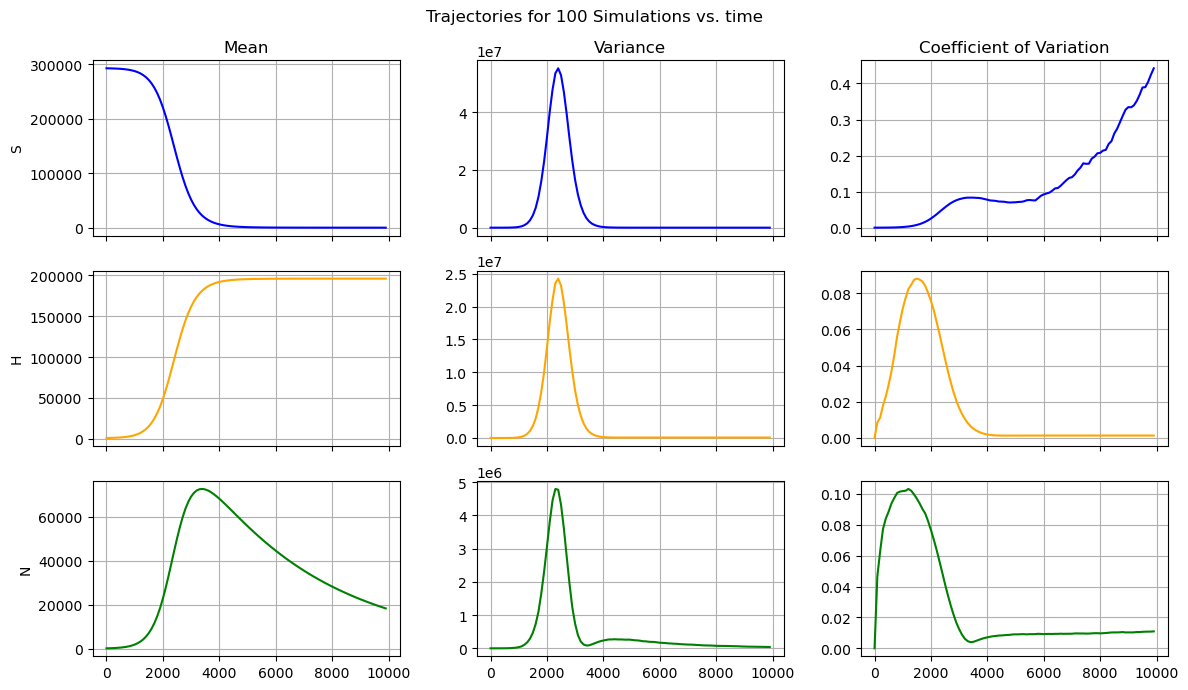

In [154]:
#plot counts vs time for each simulation
fig,ax=plt.subplots(3, 3, figsize=(12,7),sharex=True)
ax[0,0].plot(aligned_event_times, S_mean_array, c='blue')
#ax[0,0].fill_between(aligned_event_times, S_mean_array-S_variance_array, S_mean_array+S_variance_array, alpha=0.2, color='blue')
ax[0,0].set_title('Mean')
ax[0,0].set_ylabel('S')
ax[0,1].plot(aligned_event_times, S_variance_array, c='blue')
ax[0,1].set_title('Variance')
ax[0,2].plot(aligned_event_times, S_coeff_var_array, c='blue')
ax[0,2].set_title('Coefficient of Variation')

ax[1,0].plot(aligned_event_times, H_mean_array,c='orange')
#ax[1,0].fill_between(aligned_event_times, H_mean_array-H_variance_array, H_mean_array+H_variance_array, alpha=0.2, color='orange')
ax[1,0].set_ylabel('H')
ax[1,1].plot(aligned_event_times, H_variance_array,c='orange')
ax[1,2].plot(aligned_event_times, H_coeff_var_array,c='orange')

ax[2,0].plot(aligned_event_times, N_mean_array,c='green')
#ax[2,0].fill_between(aligned_event_times, N_mean_array-N_variance_array, N_mean_array+N_variance_array, alpha=0.2, color='green')
ax[2,0].set_ylabel('N')
ax[2,1].plot(aligned_event_times, N_variance_array,c='green')
ax[2,2].plot(aligned_event_times, N_coeff_var_array,c='green')


fig.suptitle(rf'Trajectories for {num_simulations} Simulations vs. time')

ax[0,0].grid()
ax[0,1].grid()
ax[0,2].grid()
ax[1,0].grid()
ax[1,1].grid()
ax[1,2].grid()
ax[2,0].grid()
ax[2,1].grid()
ax[2,2].grid()

plt.tight_layout()
fig.savefig('means,var,trajectories.png', dpi=300)

## d) Summarize results and compare to with predictions

This Gillespie model of a simplified Kombucha fermentation metabolism with this specific set of initial parameters shows, that as long there is sugar $S$, the $H$ molecules are increasing and no more change in $H$ and $S$, when all the sugar is consumend. This was already expected in the predictions.
In the beginning, starting low, the bacteria population $N$ sees exponential growth, while there is sugar and still not a too acidic milieu. When the acidity increases, the growth of $N$ dampens and as the system with these start parameters ran out of sugar, the bacteria dynamic goes from growing into degrading. In all 3 populations, the variance peaked in the growing phase of $N$ or more specific, it seems to peak at the turning point of the slope (around t=2500). Differing from the predictions, I would say now, that not only is the fluctuation coming from the exponential growth and decay, but foremost on the time difference of this turning point in the different simulations and thereby the temporal change of dynamics.
After having consumed all the sugar, the bacteria experiences an exponential decay on another timescale as growth. This and also the exponential growth cohere with the predictions.
In the predictions, I postulated also a stabilizing phase, where growth and degradation keep balance. This did not manifest with these initial conditions, because I suspect, that the sugar ran out, before it could get there.
Anyways, after seeing the these plots, I would now predict, that there is not a real stabile phase, as the pH still changes and therefore also the degradation rate. I guess therefore, that $N$ would peak and get more to a almost linear slow decrease, depending on the interplay of alpha, mu, lambda and gamma until the sugar is consumed.